# Comparative Analysis of Optimization Methods

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import os

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

def load_json(path):
    if not os.path.exists(path):
        return None
    with open(path) as f:
        return json.load(f)

lr_results = {
    'Baseline': load_json('results/results_lr_baseline.json'),
    'Grid': load_json('results/results_lr_grid.json'),
    'Random': load_json('results/results_lr_random.json'),
    'GA': load_json('results/results_lr_ga.json'),
    'Hybrid': load_json('results/results_lr_hybrid.json'),
    'RS+Local': load_json('results/results_lr_rs_local.json'),
}

lstm_results = {
    'Baseline': load_json('results/results_lstm_baseline.json'),
    'Grid': load_json('results/results_lstm_grid.json'),
    'Random': load_json('results/results_lstm_random.json'),
    'GA': load_json('results/results_lstm_ga.json'),
    'Hybrid': load_json('results/results_lstm_hybrid.json'),
}

lr_results = {k: v for k, v in lr_results.items() if v is not None}
lstm_results = {k: v for k, v in lstm_results.items() if v is not None}
print(f"LR results loaded: {list(lr_results.keys())}")
print(f"LSTM results loaded: {list(lstm_results.keys())}")

LR results loaded: ['Baseline', 'Grid', 'Random', 'GA', 'Hybrid']
LSTM results loaded: ['Baseline', 'Grid', 'Random', 'GA', 'Hybrid']


## 1. Summary Table

In [2]:
def get_metrics(result):
    if 'runs' in result:
        f1s = [r['test_metrics']['macro_f1'] for r in result['runs']]
        val_f1s = [r.get('val_f1', r.get('best_val_f1', None)) for r in result['runs']]
        evals = result['runs'][0].get('total_evaluations', result.get('total_evaluations_per_run', '?'))
        return {
            'val_f1': f"{np.mean([v for v in val_f1s if v]):.4f} ± {np.std([v for v in val_f1s if v]):.4f}",
            'test_f1': f"{np.mean(f1s):.4f} ± {np.std(f1s):.4f}",
            'test_f1_mean': np.mean(f1s),
            'evals': evals,
        }
    else:
        evals = result.get('total_evaluations', 1)
        return {
            'val_f1': f"{result.get('best_val_f1', '-')}",
            'test_f1': f"{result['test_metrics']['macro_f1']:.4f}",
            'test_f1_mean': result['test_metrics']['macro_f1'],
            'evals': evals,
        }

print(f"{'Method':<15} {'Val F1':>20} {'Test F1':>20} {'Evals':>8}")

print()
print("LR:")
for name, res in lr_results.items():
    m = get_metrics(res)
    print(f"{name:<15} {m['val_f1']:>20} {m['test_f1']:>20} {str(m['evals']):>8}")

print()
print("LSTM:")
for name, res in lstm_results.items():
    m = get_metrics(res)
    print(f"{name:<15} {m['val_f1']:>20} {m['test_f1']:>20} {str(m['evals']):>8}")

Method                        Val F1              Test F1    Evals

LR:
Baseline                           -               0.8414        1
Grid                               -               0.8576       96
Random               0.8963 ± 0.0002      0.8573 ± 0.0006       96
GA                   0.8962 ± 0.0002      0.8569 ± 0.0008       84
Hybrid               0.8963 ± 0.0001      0.8568 ± 0.0009        ?

LSTM:
Baseline                           -               0.8433        1
Grid                               -               0.8727      144
Random                             -               0.8598      144
GA                                 -               0.8681       67
Hybrid                             -               0.8727       72


## 2. Box Plot - LR Test F1 (5 runs)

C:\Users\Milana Horalevych\AppData\Local\Temp\ipykernel_14568\1843306280.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(lr_boxplot_data.values(), labels=lr_boxplot_data.keys(), patch_artist=True)


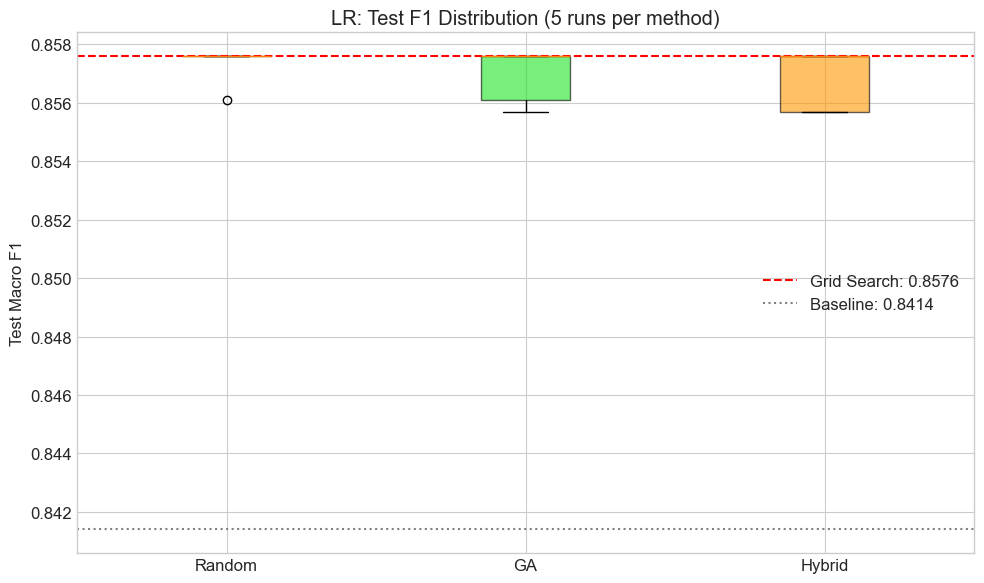

In [3]:
lr_boxplot_data = {}
for name, res in lr_results.items():
    if 'runs' in res:
        f1s = [r['test_metrics']['macro_f1'] for r in res['runs']]
        lr_boxplot_data[name] = f1s

if lr_boxplot_data:
    fig, ax = plt.subplots(figsize=(10, 6))
    bp = ax.boxplot(lr_boxplot_data.values(), labels=lr_boxplot_data.keys(), patch_artist=True)
    colors = ["#008CFF", "#1EE525", "#FF9900", "#F3255F"]
    for patch, color in zip(bp['boxes'], colors[:len(bp['boxes'])]):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)

    if 'Grid' in lr_results:
        grid_f1 = lr_results['Grid']['test_metrics']['macro_f1']
        ax.axhline(grid_f1, color='red', linestyle='--', linewidth=1.5, label=f'Grid Search: {grid_f1:.4f}')
        ax.legend()

    if 'Baseline' in lr_results:
        baseline_f1 = lr_results['Baseline']['test_metrics']['macro_f1']
        ax.axhline(baseline_f1, color='gray', linestyle=':', linewidth=1.5, label=f'Baseline: {baseline_f1:.4f}')
        ax.legend()

    ax.set_ylabel('Test Macro F1')
    ax.set_title('LR: Test F1 Distribution (5 runs per method)')
    plt.tight_layout()
    plt.savefig('results/analysis_boxplot_lr.png', dpi=150, bbox_inches='tight')
    plt.show()

## 3. Convergence Curves

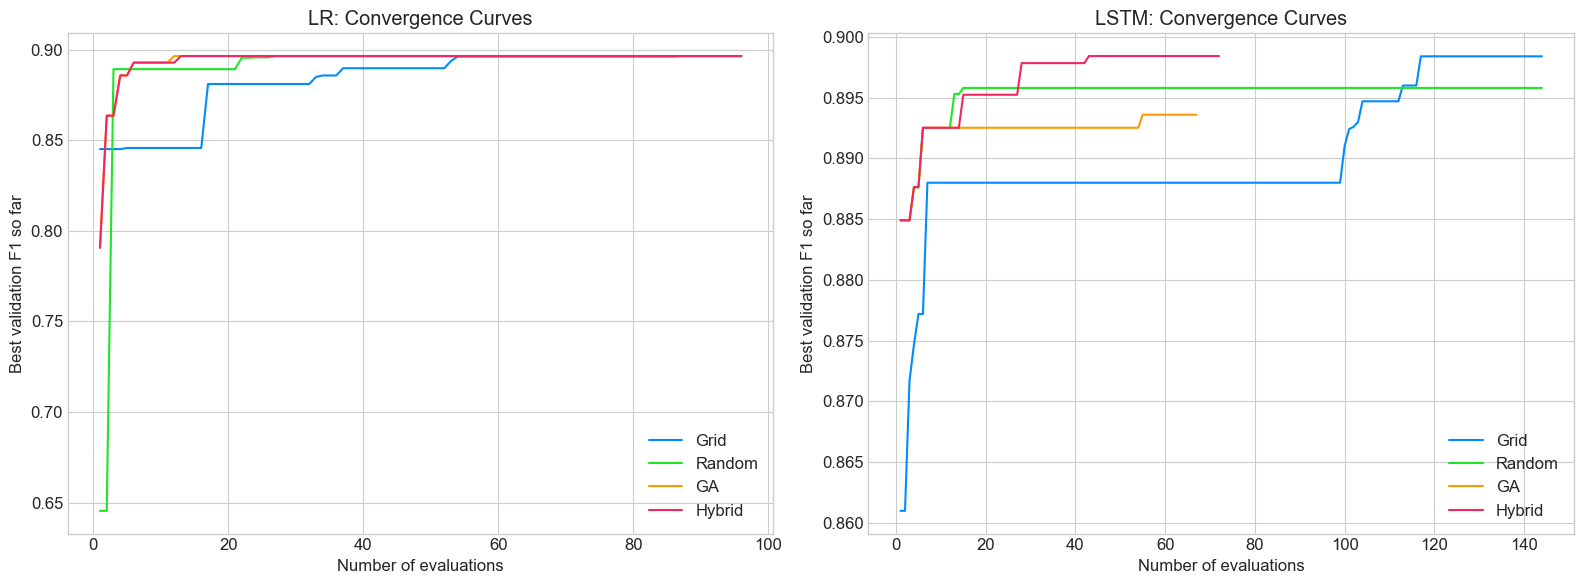

In [4]:
def extract_convergence(all_results):
    best_so_far = []
    current_best = 0
    for r in all_results:
        f1 = r.get('val_f1', r.get('fitness', 0))
        if isinstance(f1, str):
            f1 = float(f1)
        if f1 > current_best:
            current_best = f1
        best_so_far.append(current_best)
    return best_so_far

def get_convergence(res):
    for key in ['all_results', 'all_evaluations']:
        if key in res:
            return extract_convergence(res[key])
    for ga_key in ['ga_all_evaluations', 'all_ga_evaluations']:
        if ga_key in res:
            ga_conv = extract_convergence(res[ga_key])
            if 'local_results' in res:
                local_conv = extract_convergence(res['local_results'])
                local_conv = [max(ga_conv[-1], x) for x in local_conv]
                return ga_conv + local_conv
            return ga_conv
    return None

method_colors = {'Grid': '#008CFF', 'Random': '#1EE525', 'GA': '#FF9900', 'Hybrid': '#F3255F', 'RS+Local': '#9B59B6'}
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (results, title) in zip(axes, [(lr_results, 'LR'), (lstm_results, 'LSTM')]):
    for name, res in results.items():
        if name == 'Baseline':
            continue
        color = method_colors.get(name, '#888888')
        if 'runs' in res:
            f1s = [r['test_metrics']['macro_f1'] for r in res['runs']]
            median_idx = np.argsort(f1s)[len(f1s)//2]
            conv = get_convergence(res['runs'][median_idx])
        else:
            conv = get_convergence(res)
        if conv:
            ax.plot(range(1, len(conv)+1), conv, label=name, color=color)

    ax.set_xlabel('Number of evaluations')
    ax.set_ylabel('Best validation F1 so far')
    ax.set_title(f'{title}: Convergence Curves')
    ax.legend()

plt.tight_layout()
plt.savefig('results/analysis_convergence.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Hybrid vs RS+Local (Control Experiment)

In [5]:
if 'Hybrid' in lr_results and 'RS+Local' in lr_results:
    hybrid = lr_results['Hybrid']
    rs_local = lr_results['RS+Local']

    if 'runs' in hybrid and 'runs' in rs_local:
        h_f1s = [r['test_metrics']['macro_f1'] for r in hybrid['runs']]
        rs_f1s = [r['test_metrics']['macro_f1'] for r in rs_local['runs']]

        print("Hybrid (GA+Local) vs RS+Local (Control):")
        print(f"  Hybrid test F1:   {np.mean(h_f1s):.4f} ± {np.std(h_f1s):.4f}")
        print(f"  RS+Local test F1: {np.mean(rs_f1s):.4f} ± {np.std(rs_f1s):.4f}")
        print(f"  Difference:       {np.mean(h_f1s) - np.mean(rs_f1s):+.4f}")

        if np.mean(h_f1s) > np.mean(rs_f1s) + 0.005:
            print("\n  -> Hybrid > RS+Local: GA component provides advantage")
        elif np.mean(h_f1s) < np.mean(rs_f1s) - 0.005:
            print("\n  -> Hybrid < RS+Local: GA component may be harmful in Phase 1")
        else:
            print("\n  -> Hybrid ~= RS+Local: advantage comes from two-phase structure, not GA specifically")

        fig, ax = plt.subplots(figsize=(8, 5))
        bp = ax.boxplot([h_f1s, rs_f1s], labels=['Hybrid\n(GA+Local)', 'RS+Local\n(Control)'], patch_artist=True)
        bp['boxes'][0].set_facecolor('#FF9900')
        bp['boxes'][1].set_facecolor("#F3255F")
        for box in bp['boxes']:
            box.set_alpha(0.6)
        ax.set_ylabel('Test Macro F1')
        ax.set_title('LR: Hybrid vs RS+Local Control (5 runs)')
        plt.tight_layout()
        plt.savefig('results/analysis_hybrid_control.png', dpi=150, bbox_inches='tight')
        plt.show()
else:
    print("Hybrid or RS+Local results not available yet.")

Hybrid or RS+Local results not available yet.


## 5. GA: Fitness by Generation

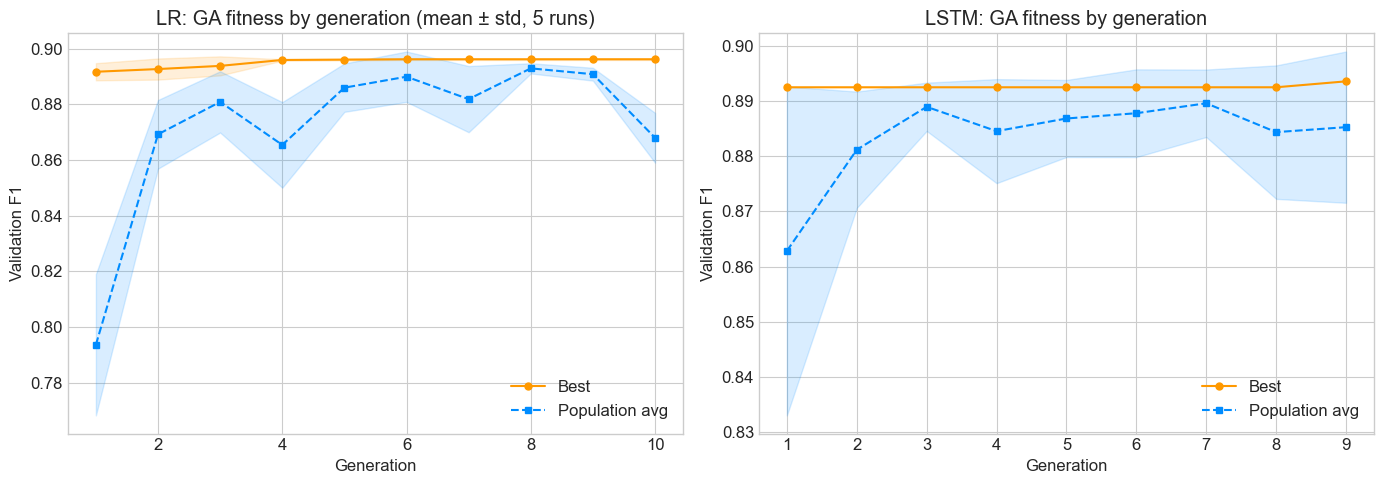

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# LR: mean across 5 runs
ax = axes[0]
lr_ga = lr_results.get('GA')
if lr_ga and 'runs' in lr_ga:
    histories = [r['history'] for r in lr_ga['runs']]
    n_gen = min(len(h) for h in histories)
    gens = range(1, n_gen + 1)
    best_arr = np.array([[h[g]['best_fitness'] for g in range(n_gen)] for h in histories])
    avg_arr = np.array([[h[g]['avg_fitness'] for g in range(n_gen)] for h in histories])

    ax.plot(gens, best_arr.mean(0), 'o-', color='#FF9900', label='Best', markersize=5)
    ax.fill_between(gens, best_arr.mean(0) - best_arr.std(0),
                    best_arr.mean(0) + best_arr.std(0), color='#FF9900', alpha=0.15)
    ax.plot(gens, avg_arr.mean(0), 's--', color='#008CFF', label='Population avg', markersize=5)
    ax.fill_between(gens, avg_arr.mean(0) - avg_arr.std(0),
                    avg_arr.mean(0) + avg_arr.std(0), color='#008CFF', alpha=0.15)
    ax.set_xlabel('Generation')
    ax.set_ylabel('Validation F1')
    ax.set_title('LR: GA fitness by generation (mean \u00b1 std, 5 runs)')
    ax.legend()

# LSTM: single run
ax = axes[1]
lstm_ga = lstm_results.get('GA')
if lstm_ga and 'history' in lstm_ga:
    h = lstm_ga['history']
    gens = [x['generation'] for x in h]
    avgs = np.array([x['avg_fitness'] for x in h])
    stds = np.array([x['std_fitness'] for x in h])
    ax.plot(gens, [x['best_fitness'] for x in h], 'o-', color='#FF9900', label='Best', markersize=5)
    ax.plot(gens, avgs, 's--', color='#008CFF', label='Population avg', markersize=5)
    ax.fill_between(gens, avgs - stds, avgs + stds, color='#008CFF', alpha=0.15)
    ax.set_xlabel('Generation')
    ax.set_ylabel('Validation F1')
    ax.set_title('LSTM: GA fitness by generation')
    ax.legend()

plt.tight_layout()
plt.savefig('results/analysis_ga_generations.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Test Metrics Comparison

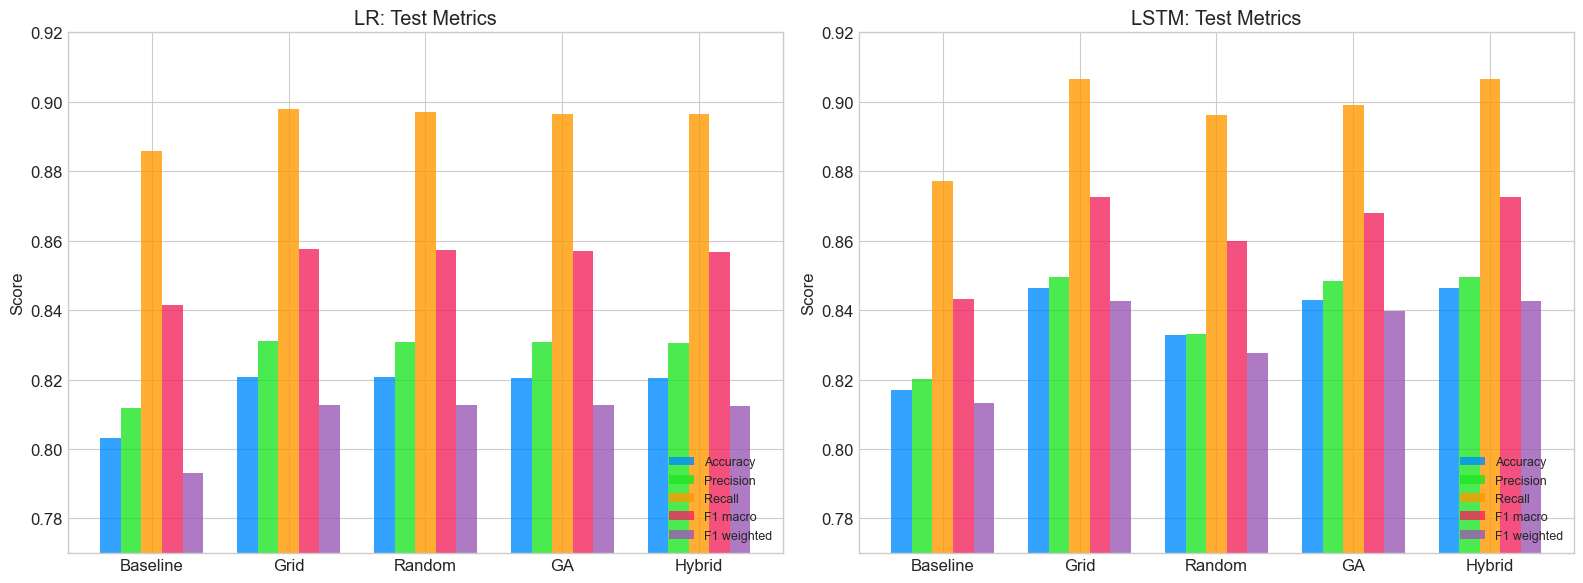

In [7]:
metric_keys = ['accuracy', 'macro_precision', 'macro_recall', 'macro_f1', 'weighted_f1']
metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1 macro', 'F1 weighted']
bar_colors = ['#008CFF', '#1EE525', '#FF9900', '#F3255F', '#9B59B6']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (results, title) in zip(axes, [(lr_results, 'LR'), (lstm_results, 'LSTM')]):
    methods = list(results.keys())
    data = {}
    for name, res in results.items():
        if 'runs' in res:
            data[name] = {k: np.mean([r['test_metrics'][k] for r in res['runs']]) for k in metric_keys}
        else:
            data[name] = {k: res['test_metrics'][k] for k in metric_keys}

    x = np.arange(len(methods))
    w = 0.15
    for i, (mk, ml, c) in enumerate(zip(metric_keys, metric_labels, bar_colors)):
        vals = [data[m][mk] for m in methods]
        ax.bar(x + (i - 2) * w, vals, w, label=ml, color=c, alpha=0.8)

    ax.set_xticks(x)
    ax.set_xticklabels(methods)
    ax.set_ylabel('Score')
    ax.set_title(f'{title}: Test Metrics')
    ax.legend(fontsize=9, loc='lower right')
    ax.set_ylim(0.77, 0.92)

plt.tight_layout()
plt.savefig('results/analysis_metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Cost-Performance Tradeoff

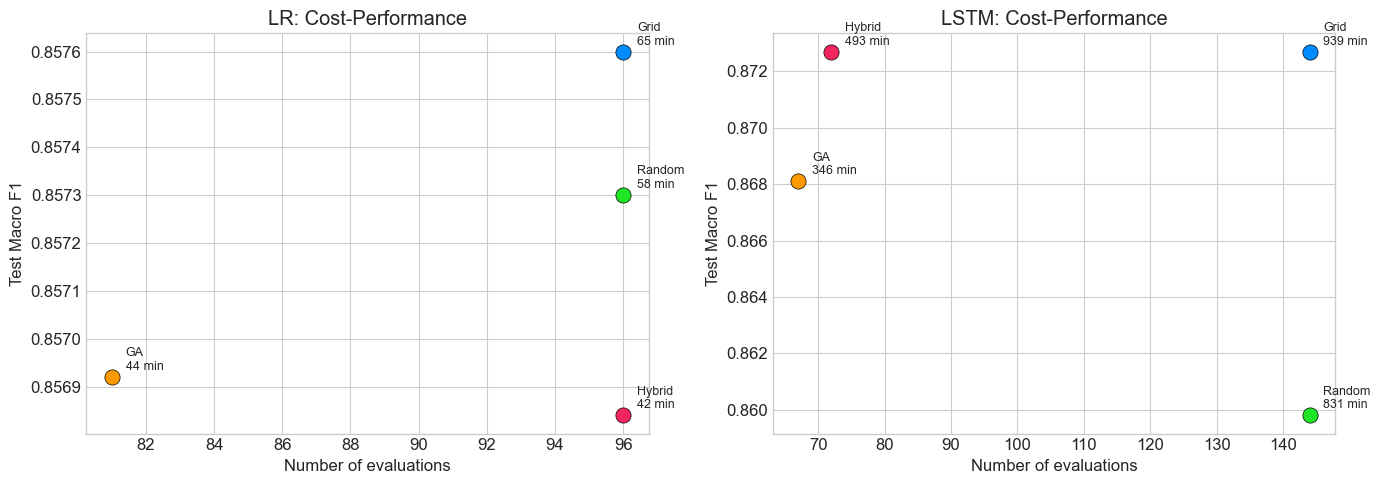

In [8]:
def get_time_and_evals(res):
    if 'runs' in res:
        times, evals_list = [], []
        for r in res['runs']:
            t = r.get('search_time_seconds', 0)
            if t == 0:
                t = r.get('ga_time_seconds', 0) + r.get('local_time_seconds', 0)
            times.append(t)
            evals_list.append(r.get('total_evaluations', r.get('total_evals', None)))
        avg_time = np.mean(times)
        valid = [e for e in evals_list if e is not None]
        avg_evals = np.mean(valid) if valid else res.get('total_evaluations_per_run', res.get('total_budget'))
        return avg_time, avg_evals
    t = res.get('search_time_seconds', res.get('training_time_seconds', 0))
    return t, res.get('total_evaluations', 1)

method_colors = {'Grid': '#008CFF', 'Random': '#1EE525', 'GA': '#FF9900', 'Hybrid': '#F3255F', 'RS+Local': '#9B59B6'}
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (results, title) in zip(axes, [(lr_results, 'LR'), (lstm_results, 'LSTM')]):
    for name, res in results.items():
        if name == 'Baseline':
            continue
        m = get_metrics(res)
        t, e = get_time_and_evals(res)
        c = method_colors.get(name, '#888888')
        ax.scatter(e, m['test_f1_mean'], s=120, c=c, edgecolors='black', linewidth=0.5, zorder=5)
        ax.annotate(f'{name}\n{t/60:.0f} min', (e, m['test_f1_mean']),
                    textcoords='offset points', xytext=(10, 5), fontsize=9)

    ax.set_xlabel('Number of evaluations')
    ax.set_ylabel('Test Macro F1')
    ax.set_title(f'{title}: Cost-Performance')

plt.tight_layout()
plt.savefig('results/analysis_cost_performance.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Best Hyperparameters

In [9]:
print("LR:")
print(f"  {'Method':<10} {'lr':>8} {'weight_decay':>14} {'batch_size':>12}")
for name, res in lr_results.items():
    if name == 'Baseline':
        continue
    hp = res['runs'][0]['best_hyperparameters'] if 'runs' in res else res.get('best_hyperparameters', {})
    print(f"  {name:<10} {hp.get('learning_rate', ''):>8} {str(hp.get('weight_decay', '')):>14} {str(hp.get('batch_size', '')):>12}")

print("\nLSTM:")
print(f"  {'Method':<10} {'emb':>5} {'hid':>5} {'layers':>7} {'drop':>6} {'lr':>8} {'bs':>4}")
for name, res in lstm_results.items():
    if name == 'Baseline':
        continue
    hp = res.get('best_hyperparameters', {})
    print(f"  {name:<10} {hp.get('embedding_dim',''):>5} {hp.get('hidden_dim',''):>5} "
          f"{hp.get('num_layers',''):>7} {hp.get('dropout',''):>6} "
          f"{hp.get('learning_rate',''):>8} {hp.get('batch_size',''):>4}")

LR:
  Method           lr   weight_decay   batch_size
  Grid           0.05          1e-05          128
  Random         0.05          1e-05          128
  GA             0.05          1e-05          128
  Hybrid         0.05          1e-05          128

LSTM:
  Method       emb   hid  layers   drop       lr   bs
  Grid         256   256       1    0.5    0.001   32
  Random       256   128       1    0.4    0.005   64
  GA           256   128       1    0.2    0.005  128
  Hybrid       256   256       1    0.5    0.001   32
